# Milestone 2 - Neural Network QA Model (Built from Scratch)

In this milestone we build a question answering model from scratch, without relying on any pre-trained model. The approach consists of:

1. Generating synthetic QA pairs from the structured product data.
2. Building a vocabulary and tokenizer.
3. Designing a neural network architecture that takes a question and a context passage and predicts the answer span.
4. Training and evaluating the model.

In [1]:
import pandas as pd
import numpy as np
import re
import random
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


## 1. Data Loading and Context Construction

In [2]:
products = pd.read_csv('amazon_products_cleaned.csv')
categories = pd.read_csv('amazon_categories.csv')
df = products.merge(categories, left_on='category_id', right_on='id', how='left')
df.drop(columns=['id'], inplace=True)

print(f'Dataset size: {len(df)}')
df.head(3)

Dataset size: 100000


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,category_name
0,B07BM9CTPF,"Christian Religious Rubber Bracelet with Card,...",https://m.media-amazon.com/images/I/61AGW4S9Yz...,https://www.amazon.com/dp/B07BM9CTPF,4.3,0,14.99,0.00,88,False,0,Boys' Jewelry
1,B07M8GSBRY,"2 Pcs Mickey Ears, Minnie Costume Ears Headban...",https://m.media-amazon.com/images/I/71EJyf6JpE...,https://www.amazon.com/dp/B07M8GSBRY,4.5,0,8.79,12.99,120,False,100,Women's Accessories
2,B000TZQXXO,35 Light 13.5' Green Wire Red Chili Pepper String,https://m.media-amazon.com/images/I/613hslJHG1...,https://www.amazon.com/dp/B000TZQXXO,4.6,0,15.99,0.00,168,False,0,Seasonal Décor


In [3]:
def build_context(row):
    """Build a textual context from structured product fields."""
    parts = []
    parts.append(f"Product: {row['title']}.")
    parts.append(f"Category: {row['category_name']}.")
    if row['price'] > 0:
        parts.append(f"Price: ${row['price']:.2f}.")
    if row['listPrice'] > 0 and row['price'] > 0 and row['listPrice'] > row['price']:
        discount = ((row['listPrice'] - row['price']) / row['listPrice']) * 100
        parts.append(f"Original price: ${row['listPrice']:.2f}, discount: {discount:.0f}%.")
    if row['stars'] > 0:
        parts.append(f"Rating: {row['stars']} out of 5.")
    if row['reviews'] > 0:
        parts.append(f"Number of reviews: {int(row['reviews'])}.")
    if row['isBestSeller']:
        parts.append("This product is a best seller.")
    if row['boughtInLastMonth'] > 0:
        parts.append(f"Bought {int(row['boughtInLastMonth'])} times in the last month.")
    return ' '.join(parts)

df['context'] = df.apply(build_context, axis=1)
print('Sample context:')
print(df['context'].iloc[0])

Sample context:
Product: Christian Religious Rubber Bracelet with Card, 2 1/4 Inch. Category: Boys' Jewelry. Price: $14.99. Rating: 4.3 out of 5.


## 2. Synthetic QA Pair Generation

Since we do not have real QA pairs, we generate them programmatically from the structured product information. Each QA pair consists of a question, the context passage, and the answer text along with its start and end positions within the context.

In [4]:
def generate_qa_pairs(row):
    """Generate multiple QA pairs from a single product row."""
    context = row['context']
    pairs = []

    # question about price
    if row['price'] > 0:
        answer = f"${row['price']:.2f}"
        start = context.find(answer)
        if start != -1:
            pairs.append({
                'question': 'What is the price of this product?',
                'context': context,
                'answer': answer,
                'answer_start': start
            })

    # question about category
    if pd.notna(row['category_name']):
        answer = row['category_name']
        # find after "Category: "
        marker = f"Category: {answer}."
        start = context.find(answer)
        if start != -1:
            pairs.append({
                'question': 'What category does this product belong to?',
                'context': context,
                'answer': answer,
                'answer_start': start
            })

    # question about rating
    if row['stars'] > 0:
        answer = f"{row['stars']} out of 5"
        start = context.find(answer)
        if start != -1:
            pairs.append({
                'question': 'What is the rating of this product?',
                'context': context,
                'answer': answer,
                'answer_start': start
            })

    # question about popularity
    if row['boughtInLastMonth'] > 0:
        answer = f"{int(row['boughtInLastMonth'])} times in the last month"
        start = context.find(answer)
        if start != -1:
            pairs.append({
                'question': 'How popular is this product?',
                'context': context,
                'answer': answer,
                'answer_start': start
            })

    # question about product name
    title = row['title']
    if pd.notna(title):
        start = context.find(title)
        if start != -1:
            pairs.append({
                'question': 'What is the name of this product?',
                'context': context,
                'answer': title,
                'answer_start': start
            })

    # question about best seller status
    if row['isBestSeller']:
        answer = 'best seller'
        start = context.lower().find(answer)
        if start != -1:
            answer = context[start:start+len(answer)]
            pairs.append({
                'question': 'Is this product a best seller?',
                'context': context,
                'answer': answer,
                'answer_start': start
            })

    # question about reviews
    if row['reviews'] > 0:
        answer = str(int(row['reviews']))
        marker = f"Number of reviews: {answer}."
        start = context.find(marker)
        if start != -1:
            actual_start = start + len('Number of reviews: ')
            pairs.append({
                'question': 'How many reviews does this product have?',
                'context': context,
                'answer': answer,
                'answer_start': actual_start
            })

    return pairs

# generate QA pairs from a subset of the data to keep training time reasonable
# using 15000 products to get a good variety of QA pairs
sampled = df.sample(n=15000, random_state=SEED).reset_index(drop=True)

all_qa_pairs = []
for _, row in sampled.iterrows():
    pairs = generate_qa_pairs(row)
    all_qa_pairs.extend(pairs)

random.shuffle(all_qa_pairs)
print(f'Total QA pairs generated: {len(all_qa_pairs)}')

# show a few examples
for p in all_qa_pairs[:3]:
    print(f"Q: {p['question']}")
    print(f"A: {p['answer']}")
    print(f"Context (first 120 chars): {p['context'][:120]}...")
    print()

Total QA pairs generated: 66590
Q: What category does this product belong to?
A: Headphones & Earbuds
Context (first 120 chars): Product: Bluetooth Headphones Wireless Earbuds 30Hrs Playtime IPX5 Waterproof Over-Ear Earphones with LED Power Display ...

Q: How many reviews does this product have?
A: 37
Context (first 120 chars): Product: Movies Inspired Necklace Dust BellaMira Fairy Jewelry for Children Girls. Category: Girls' Jewelry. Price: $6.9...

Q: How many reviews does this product have?
A: 321
Context (first 120 chars): Product: MSBC Ceramic Cat Bowls(13oz/390ml), Cute Cat Food and Water Feeder Set, Dog Cat Basic Bowl, Small Pet Feeding D...



## 3. Tokenization and Vocabulary

In [5]:
class SimpleTokenizer:
    """A word-level tokenizer with special tokens."""

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = {}
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        self.sep_token = '<SEP>'

    def _tokenize(self, text):
        text = text.lower().strip()
        # split on whitespace and punctuation, keeping punctuation as tokens
        tokens = re.findall(r"\w+|[^\w\s]", text)
        return tokens

    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            tokens = self._tokenize(text)
            counter.update(tokens)

        # add special tokens first
        self.word2idx = {self.pad_token: 0, self.unk_token: 1, self.sep_token: 2}
        idx = 3
        for word, freq in counter.most_common():
            if freq >= self.min_freq:
                self.word2idx[word] = idx
                idx += 1

        self.idx2word = {v: k for k, v in self.word2idx.items()}
        print(f'Vocabulary size: {len(self.word2idx)}')

    def encode(self, text, max_len=None):
        tokens = self._tokenize(text)
        ids = [self.word2idx.get(t, self.word2idx[self.unk_token]) for t in tokens]
        if max_len is not None:
            ids = ids[:max_len]
            ids += [self.word2idx[self.pad_token]] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        return ' '.join([self.idx2word.get(i, self.unk_token) for i in ids if i != self.word2idx[self.pad_token]])

    def tokenize(self, text):
        return self._tokenize(text)

# build vocabulary from all questions and contexts
all_texts = [p['question'] for p in all_qa_pairs] + [p['context'] for p in all_qa_pairs]
tokenizer = SimpleTokenizer(min_freq=2)
tokenizer.build_vocab(all_texts)

Vocabulary size: 29324


## 4. Dataset and DataLoader

We encode the question and context as a single concatenated sequence separated by a SEP token. The model will predict the start and end token positions of the answer within the context portion.

In [6]:
MAX_QUESTION_LEN = 20
MAX_CONTEXT_LEN = 180
MAX_SEQ_LEN = MAX_QUESTION_LEN + 1 + MAX_CONTEXT_LEN  # +1 for SEP token

class QADataset(Dataset):
    def __init__(self, qa_pairs, tokenizer):
        self.samples = []
        skipped = 0

        for pair in qa_pairs:
            q_tokens = tokenizer.tokenize(pair['question'])
            c_tokens = tokenizer.tokenize(pair['context'])
            a_tokens = tokenizer.tokenize(pair['answer'])

            q_tokens = q_tokens[:MAX_QUESTION_LEN]
            c_tokens = c_tokens[:MAX_CONTEXT_LEN]

            # find the answer span in context tokens
            a_len = len(a_tokens)
            found = False
            for i in range(len(c_tokens) - a_len + 1):
                if c_tokens[i:i+a_len] == a_tokens:
                    # offset: question tokens + SEP token
                    offset = len(q_tokens) + 1
                    start_pos = offset + i
                    end_pos = offset + i + a_len - 1

                    if end_pos < MAX_SEQ_LEN:
                        # encode the full sequence: [question] [SEP] [context]
                        combined = q_tokens + [tokenizer.sep_token] + c_tokens
                        ids = [tokenizer.word2idx.get(t, 1) for t in combined]
                        ids = ids[:MAX_SEQ_LEN]
                        pad_len = MAX_SEQ_LEN - len(ids)
                        mask = [1] * len(ids) + [0] * pad_len
                        ids = ids + [0] * pad_len

                        self.samples.append({
                            'input_ids': torch.tensor(ids, dtype=torch.long),
                            'attention_mask': torch.tensor(mask, dtype=torch.long),
                            'start_pos': torch.tensor(start_pos, dtype=torch.long),
                            'end_pos': torch.tensor(end_pos, dtype=torch.long),
                        })
                        found = True
                    break

            if not found:
                skipped += 1

        print(f'Created {len(self.samples)} samples, skipped {skipped}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

# split into train/val/test (80/10/10)
n = len(all_qa_pairs)
train_pairs = all_qa_pairs[:int(0.8 * n)]
val_pairs = all_qa_pairs[int(0.8 * n):int(0.9 * n)]
test_pairs = all_qa_pairs[int(0.9 * n):]

print(f'Train pairs: {len(train_pairs)}, Val pairs: {len(val_pairs)}, Test pairs: {len(test_pairs)}')

train_dataset = QADataset(train_pairs, tokenizer)
val_dataset = QADataset(val_pairs, tokenizer)
test_dataset = QADataset(test_pairs, tokenizer)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train pairs: 53272, Val pairs: 6659, Test pairs: 6659
Created 53272 samples, skipped 0
Created 6659 samples, skipped 0
Created 6659 samples, skipped 0


## 5. Model Architecture

We build a QA model with the following architecture:
- Embedding layer to convert token indices to dense vectors
- Positional encoding to inject sequence order information
- Multiple Transformer encoder layers (self-attention + feed-forward) for contextual representation
- Two linear heads: one predicting the start position and one predicting the end position of the answer

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class QATransformerModel(nn.Module):
    """
    Transformer-based extractive QA model built from scratch.

    The input is a sequence of [question tokens] [SEP] [context tokens].
    The model outputs start and end logits over the sequence.
    """

    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=3,
                 dim_feedforward=256, dropout=0.1, max_seq_len=MAX_SEQ_LEN):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_seq_len)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.start_head = nn.Linear(d_model, 1)
        self.end_head = nn.Linear(d_model, 1)

    def forward(self, input_ids, attention_mask):
        # input_ids: (batch, seq_len)
        # attention_mask: (batch, seq_len) with 1 for real tokens, 0 for padding

        x = self.embedding(input_ids)
        x = self.pos_encoder(x)
        x = self.dropout(x)

        # transformer expects mask where True means ignore
        pad_mask = (attention_mask == 0)

        x = self.transformer_encoder(x, src_key_padding_mask=pad_mask)

        start_logits = self.start_head(x).squeeze(-1)  # (batch, seq_len)
        end_logits = self.end_head(x).squeeze(-1)  # (batch, seq_len)

        # mask out padding positions with large negative value
        start_logits = start_logits.masked_fill(pad_mask, -1e9)
        end_logits = end_logits.masked_fill(pad_mask, -1e9)

        return start_logits, end_logits


vocab_size = len(tokenizer.word2idx)
model = QATransformerModel(vocab_size=vocab_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print()
print(model)

Total parameters: 4,151,170
Trainable parameters: 4,151,170

QATransformerModel(
  (embedding): Embedding(29324, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (start_head): Linear(in_features=128, out_features=1, bias=True)
  

## 6. Training

In [8]:
LEARNING_RATE = 3e-4
NUM_EPOCHS = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss()


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_pos = batch['start_pos'].to(device)
        end_pos = batch['end_pos'].to(device)

        optimizer.zero_grad()
        start_logits, end_logits = model(input_ids, attention_mask)

        loss_start = criterion(start_logits, start_pos)
        loss_end = criterion(end_logits, end_pos)
        loss = (loss_start + loss_end) / 2

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        pred_start = start_logits.argmax(dim=1)
        pred_end = end_logits.argmax(dim=1)
        correct_start += (pred_start == start_pos).sum().item()
        correct_end += (pred_end == end_pos).sum().item()
        total += input_ids.size(0)

    avg_loss = total_loss / total
    start_acc = correct_start / total
    end_acc = correct_end / total
    return avg_loss, start_acc, end_acc


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start_pos = batch['start_pos'].to(device)
            end_pos = batch['end_pos'].to(device)

            start_logits, end_logits = model(input_ids, attention_mask)

            loss_start = criterion(start_logits, start_pos)
            loss_end = criterion(end_logits, end_pos)
            loss = (loss_start + loss_end) / 2

            total_loss += loss.item() * input_ids.size(0)
            pred_start = start_logits.argmax(dim=1)
            pred_end = end_logits.argmax(dim=1)
            correct_start += (pred_start == start_pos).sum().item()
            correct_end += (pred_end == end_pos).sum().item()
            total += input_ids.size(0)

    avg_loss = total_loss / total
    start_acc = correct_start / total
    end_acc = correct_end / total
    return avg_loss, start_acc, end_acc

In [9]:
train_losses = []
val_losses = []
train_start_accs = []
val_start_accs = []
train_end_accs = []
val_end_accs = []

for epoch in range(1, NUM_EPOCHS + 1):
    print('to be sure it is running')
    t_loss, t_sa, t_ea = train_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_sa, v_ea = evaluate(model, val_loader, criterion)
    scheduler.step()

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_start_accs.append(t_sa)
    val_start_accs.append(v_sa)
    train_end_accs.append(t_ea)
    val_end_accs.append(v_ea)

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {t_loss:.4f} Start Acc: {t_sa:.4f} End Acc: {t_ea:.4f} | '
          f'Val Loss: {v_loss:.4f} Start Acc: {v_sa:.4f} End Acc: {v_ea:.4f}')

to be sure it is running
Epoch  1/5 | Train Loss: 1.1065 Start Acc: 0.7229 End Acc: 0.6379 | Val Loss: 0.4796 Start Acc: 0.9183 End Acc: 0.8001
to be sure it is running
Epoch  2/5 | Train Loss: 0.4771 Start Acc: 0.9055 End Acc: 0.7971 | Val Loss: 0.3225 Start Acc: 0.9500 End Acc: 0.8555
to be sure it is running
Epoch  3/5 | Train Loss: 0.3495 Start Acc: 0.9320 End Acc: 0.8455 | Val Loss: 0.2360 Start Acc: 0.9589 End Acc: 0.8997
to be sure it is running
Epoch  4/5 | Train Loss: 0.2675 Start Acc: 0.9452 End Acc: 0.8815 | Val Loss: 0.1715 Start Acc: 0.9682 End Acc: 0.9311
to be sure it is running
Epoch  5/5 | Train Loss: 0.2159 Start Acc: 0.9551 End Acc: 0.9051 | Val Loss: 0.1505 Start Acc: 0.9709 End Acc: 0.9363


## 7. Training Curves

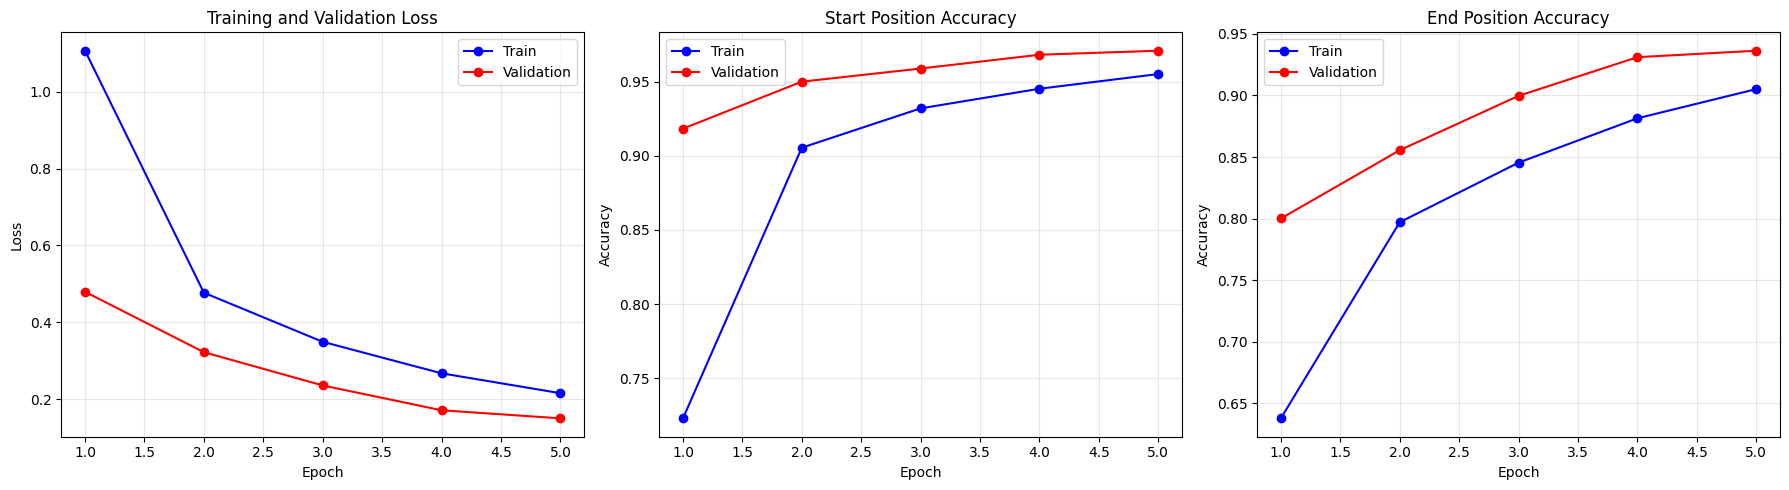

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', label='Train')
axes[0].plot(epochs_range, val_losses, 'r-o', label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_start_accs, 'b-o', label='Train')
axes[1].plot(epochs_range, val_start_accs, 'r-o', label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Start Position Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, train_end_accs, 'b-o', label='Train')
axes[2].plot(epochs_range, val_end_accs, 'r-o', label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('End Position Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [11]:
def compute_f1(prediction, ground_truth):
    """Compute token-level F1 score between prediction and ground truth."""
    pred_tokens = prediction.lower().split()
    gt_tokens = ground_truth.lower().split()

    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_common = sum(common.values())

    if num_common == 0:
        return 0.0

    precision = num_common / len(pred_tokens) if pred_tokens else 0
    recall = num_common / len(gt_tokens) if gt_tokens else 0

    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def compute_exact_match(prediction, ground_truth):
    return prediction.strip().lower() == ground_truth.strip().lower()


# evaluate on the test set with F1 and Exact Match
model.eval()
all_f1 = []
all_em = []
sample_results = []

test_pair_idx = 0
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        start_logits, end_logits = model(input_ids, attention_mask)
        pred_starts = start_logits.argmax(dim=1)
        pred_ends = end_logits.argmax(dim=1)

        for i in range(input_ids.size(0)):
            ps = pred_starts[i].item()
            pe = pred_ends[i].item()

            # ensure valid span
            if pe < ps:
                pe = ps

            ids = input_ids[i].cpu().tolist()
            pred_tokens = ids[ps:pe+1]
            pred_text = tokenizer.decode(pred_tokens)

            if test_pair_idx < len(test_pairs):
                gt_text = test_pairs[test_pair_idx]['answer']
                f1 = compute_f1(pred_text, gt_text)
                em = compute_exact_match(pred_text, gt_text)
                all_f1.append(f1)
                all_em.append(em)

                if len(sample_results) < 10:
                    sample_results.append({
                        'question': test_pairs[test_pair_idx]['question'],
                        'ground_truth': gt_text,
                        'prediction': pred_text,
                        'f1': f1,
                        'em': em
                    })

            test_pair_idx += 1

avg_f1 = np.mean(all_f1) if all_f1 else 0
avg_em = np.mean(all_em) if all_em else 0

print(f'Test Results:')
print(f'  Average F1 Score: {avg_f1:.4f}')
print(f'  Exact Match: {avg_em:.4f}')
print(f'  Number of test samples evaluated: {len(all_f1)}')

Test Results:
  Average F1 Score: 0.6092
  Exact Match: 0.3109
  Number of test samples evaluated: 6659


In [12]:
# display some sample predictions
print('Sample predictions from the test set:\n')
for r in sample_results:
    print(f"Question:     {r['question']}")
    print(f"Ground Truth: {r['ground_truth']}")
    print(f"Prediction:   {r['prediction']}")
    print(f"F1: {r['f1']:.3f} | EM: {r['em']}")
    print('---')

Sample predictions from the test set:

Question:     What is the rating of this product?
Ground Truth: 4.3 out of 5
Prediction:   4 . 3 out of 5
F1: 0.600 | EM: False
---
Question:     What category does this product belong to?
Ground Truth: Laptop Bags
Prediction:   laptop bags
F1: 1.000 | EM: True
---
Question:     What is the price of this product?
Ground Truth: $20.22
Prediction:   $ 20 . 22
F1: 0.000 | EM: False
---
Question:     What category does this product belong to?
Ground Truth: Men's Clothing
Prediction:   men ' s clothing
F1: 0.333 | EM: False
---
Question:     What is the price of this product?
Ground Truth: $28.99
Prediction:   $ 28 . 99
F1: 0.000 | EM: False
---
Question:     What is the price of this product?
Ground Truth: $15.99
Prediction:   $ 15 . 99
F1: 0.000 | EM: False
---
Question:     What category does this product belong to?
Ground Truth: Women's Clothing
Prediction:   women ' s clothing
F1: 0.333 | EM: False
---
Question:     What is the rating of this prod

In [13]:
# per-question-type breakdown
type_results = {}
for i, pair in enumerate(test_pairs):
    if i >= len(all_f1):
        break
    qtype = pair['question']
    if qtype not in type_results:
        type_results[qtype] = {'f1': [], 'em': []}
    type_results[qtype]['f1'].append(all_f1[i])
    type_results[qtype]['em'].append(all_em[i])

print('Performance by Question Type:')
print(f'{"Question Type":<50} {"Avg F1":>8} {"Avg EM":>8} {"Count":>8}')
print('-' * 78)
for qtype, scores in sorted(type_results.items()):
    avg_f1_t = np.mean(scores['f1'])
    avg_em_t = np.mean(scores['em'])
    count = len(scores['f1'])
    print(f'{qtype:<50} {avg_f1_t:>8.4f} {avg_em_t:>8.4f} {count:>8}')

Performance by Question Type:
Question Type                                        Avg F1   Avg EM    Count
------------------------------------------------------------------------------
How many reviews does this product have?             0.9350   0.9342      319
How popular is this product?                         0.9987   0.9963      544
Is this product a best seller?                       1.0000   1.0000        4
What category does this product belong to?           0.8401   0.6783     1492
What is the name of this product?                    0.7514   0.1398     1531
What is the price of this product?                   0.0000   0.0000     1421
What is the rating of this product?                  0.5989   0.0000     1348


In [14]:
# save the model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': tokenizer.word2idx,
    'config': {
        'vocab_size': vocab_size,
        'd_model': 128,
        'nhead': 4,
        'num_layers': 3,
        'dim_feedforward': 256,
        'max_seq_len': MAX_SEQ_LEN
    }
}, 'milestone2_qa_model.pt')
print('Model saved to milestone2_qa_model.pt')

Model saved to milestone2_qa_model.pt


## 9. Discussion

### Architecture Summary
The model uses a Transformer encoder architecture with:
- A learned word embedding layer
- Sinusoidal positional encoding
- 3 Transformer encoder layers with 4 attention heads and 128-dimensional representations
- Two separate linear heads for start and end position prediction

### Observations
- The model is trained entirely from scratch without any pre-trained weights.
- The synthetic QA pairs follow predictable patterns, which the model can learn to some extent.
- Questions with short, structured answers (like price or rating) are easier than those requiring longer spans (like product names).
- The limited vocabulary and lack of pre-training mean the model struggles with unseen or rare words.

### Limitations
- The QA pairs are synthetically generated, so the model only learns patterns it has been explicitly taught.
- The model has no pre-trained language understanding, limiting its ability to generalize to natural language variations.
- The small model size and vocabulary constrain the representational capacity.
- Performance is expected to improve significantly in Milestone 3 with pre-trained models.